# MTA Service Reliability Analysis
## 01: Exploration

Goal:
Identify factors associated with changes in subway on-time performance.

Datasets:
1. Terminal On-Time Performance
2. Delay-Causing Incidents

Questions:
- Which lines are most reliable?
- Which lines are least reliable?
- How has reliability changed over time?
- Which delay categories occur most often?
- Which delay categories appear associated with lower OTP?

---
### Imports

In [161]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import os

pd.set_option("display.max_columns", None)

---
### Load Data

In [3]:
otp_df = pd.read_csv("../data/raw/on_time_performance.csv")
delays_df = pd.read_csv("../data/raw/delay_incidents.csv")

---
### Inspect Data

**On-Time Performance:**

In [4]:
otp_df.head()

,month,division,line,day_type,num_on_time_trips,num_sched_trips,terminal_on_time_performance
0,2015-01-01,A DIVISION,1,1,6874,9017,0.762338
1,2015-01-01,A DIVISION,2,1,2920,6175,0.472874
2,2015-01-01,A DIVISION,3,1,4004,5834,0.686322
3,2015-01-01,A DIVISION,4,1,3692,7623,0.484324
4,2015-01-01,A DIVISION,5,1,3203,6491,0.493452


In [5]:
otp_df["month"].min(), otp_df["month"].max()

('2015-01-01', '2026-04-01')

The range of dates in the "On-Time Performance" dataset is from 2015 to 2026.

In [6]:
otp_df["division"].unique()

<StringArray>
['A DIVISION', 'B DIVISION']
Length: 2, dtype: str

A Divison trains are the numbered lines (1,2,3,4,5,6,7) and B Division trains are the lettered lines (A, B, C, D, E, F, G, J, L, M, N, Q, R, W, Z).

In [7]:
otp_df["day_type"].unique()

array([1, 2])

In [8]:
otp_df["terminal_on_time_performance"].min(), otp_df["terminal_on_time_performance"].max()

(np.float64(0.244907063), np.float64(1.0))

The minimum on time performance was 24%, it might be worth investigating.

This dataset represents weekdays as 1, weekends as 2.

In [9]:
otp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5002 entries, 0 to 5001
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   month                         5002 non-null   str    
 1   division                      5002 non-null   str    
 2   line                          5002 non-null   str    
 3   day_type                      5002 non-null   int64  
 4   num_on_time_trips             5002 non-null   int64  
 5   num_sched_trips               5002 non-null   int64  
 6   terminal_on_time_performance  5002 non-null   float64
dtypes: float64(1), int64(3), str(3)
memory usage: 273.7 KB


In [10]:
otp_df.isna().sum()

month                           0
division                        0
line                            0
day_type                        0
num_on_time_trips               0
num_sched_trips                 0
terminal_on_time_performance    0
dtype: int64

All 5002 rows are non-null in the "On-time Performance" dataset, so we do not need to worry about handling missing values.

In [11]:
otp_df.describe()

,day_type,num_on_time_trips,num_sched_trips,terminal_on_time_performance
count,5002.000000,5002.000000,5002.000000,5002.000000
mean,1.372651,4319.916833,5505.904038,0.797265
std,0.483559,2854.014547,3386.041672,0.144044
min,1.000000,168.000000,168.000000,0.244907
25%,1.000000,2078.250000,2428.500000,0.712730
50%,1.000000,3611.000000,5305.500000,0.812633
75%,2.000000,5514.500000,7494.000000,0.908598
max,2.000000,27578.000000,28040.000000,1.000000


**Delay Incidents:**

In [12]:
delays_df.head()

,Month,Division,Line,Day Type,Reporting Category,Incidents
0,2020-01-01,A DIVISION,1,1,NaN,0
1,2020-01-01,A DIVISION,1,1,Crew Availability,3
2,2020-01-01,A DIVISION,1,1,External Factors,2
3,2020-01-01,A DIVISION,1,1,Infrastructure & Equipment,43
4,2020-01-01,A DIVISION,1,1,Operating Conditions,104


In [13]:
delays_df["Month"].min(), delays_df["Month"].max()

('2020-01-01', '2026-04-01')

The range of dates in the "Delay Incidents" dataset is from 2020 to 2026. Since the OTP dataset is from 2015, we will probably need to filter the dates in it to only include 2020-2026.

In [14]:
delays_df["Line"].unique()

<StringArray>
[     '1',      '2',      '3',      '4',      '5',      '6',      '7',
 'S 42nd',      'A',      'B',      'C',      'D',      'E',      'F',
      'G',     'JZ',      'L',      'M',      'N',      'Q',      'R',
 'S Fkln', 'S Rock']
Length: 23, dtype: str

In [15]:
delays_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23702 entries, 0 to 23701
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Month               23702 non-null  str  
 1   Division            23702 non-null  str  
 2   Line                23702 non-null  str  
 3   Day Type            23702 non-null  int64
 4   Reporting Category  20316 non-null  str  
 5   Incidents           23702 non-null  int64
dtypes: int64(2), str(4)
memory usage: 1.1 MB


In [19]:
delays_df.isna().sum()

Month                    0
Division                 0
Line                     0
Day Type                 0
Reporting Category    3386
Incidents                0
dtype: int64

In the "Delay Incidents" dataset, 3,386 values are missing for "Reporting Category", so we would need ot handle that. Given that the dataset size is 23,702 rows, we should not remove the rows missing a "Reporting Category" because it's ~14.29% of the dataset. Instead, we will replace the missing values with the word "Unknown".

In [16]:
delays_df["Reporting Category"].unique()

<StringArray>
[                         nan,          'Crew Availability',
           'External Factors', 'Infrastructure & Equipment',
       'Operating Conditions',           'Planned ROW Work',
           'Police & Medical']
Length: 7, dtype: str

In [17]:
delays_df.describe()

,Day Type,Incidents
count,23702.000000,23702.000000
mean,1.486415,18.763902
std,0.499826,25.813336
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,8.000000
75%,2.000000,27.000000
max,2.000000,355.000000


---
### Clean and Join Data

In [18]:
delays_df[delays_df["Reporting Category"].isna()].head(20)

,Month,Division,Line,Day Type,Reporting Category,Incidents
0,2020-01-01,A DIVISION,1,1,NaN,0
7,2020-01-01,A DIVISION,1,2,NaN,0
14,2020-01-01,A DIVISION,2,1,NaN,0
21,2020-01-01,A DIVISION,2,2,NaN,0
28,2020-01-01,A DIVISION,3,1,NaN,0
35,2020-01-01,A DIVISION,3,2,NaN,0
42,2020-01-01,A DIVISION,4,1,NaN,0
49,2020-01-01,A DIVISION,4,2,NaN,0
56,2020-01-01,A DIVISION,5,1,NaN,0
63,2020-01-01,A DIVISION,5,2,NaN,0


In [19]:
delays_df[delays_df["Reporting Category"].isna()]["Incidents"].describe()

count    3386.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Incidents, dtype: float64

In [20]:
missing = delays_df[delays_df["Reporting Category"].isna()]

missing["Incidents"].value_counts()

Incidents
0    3386
Name: count, dtype: int64

Every single missing-category row has 0 incidents. This makes sense because if there are no incidents, there is no delay category to report. These rows don't help the analysis, so I will remove them.

In [24]:
delays_df = delays_df.dropna(subset=["Reporting Category"])
len(delays_df)

20316

Rows with missing Reporting Category were removed because all such rows corresponded to zero incidents and did not contribute information to delay-category analysis.

---
### Explore

Exploring on-time performance across different lines.

In [30]:
line_performance = otp_df.groupby("line")["terminal_on_time_performance"].mean().sort_values()
line_performance

line
2         0.645832
B         0.685165
F         0.694507
W         0.694793
N         0.706398
A         0.713316
4         0.714965
C         0.722388
D         0.739677
5         0.755298
6         0.756281
3         0.766670
E         0.768131
R         0.769315
JZ        0.776646
Q         0.778565
1         0.838304
G         0.839484
M         0.839490
7         0.875974
J         0.876711
L         0.924140
S Rock    0.952305
H         0.965122
FS        0.992632
S 42nd    0.994019
GS        0.994687
S Fkln    0.995176
Name: terminal_on_time_performance, dtype: float64

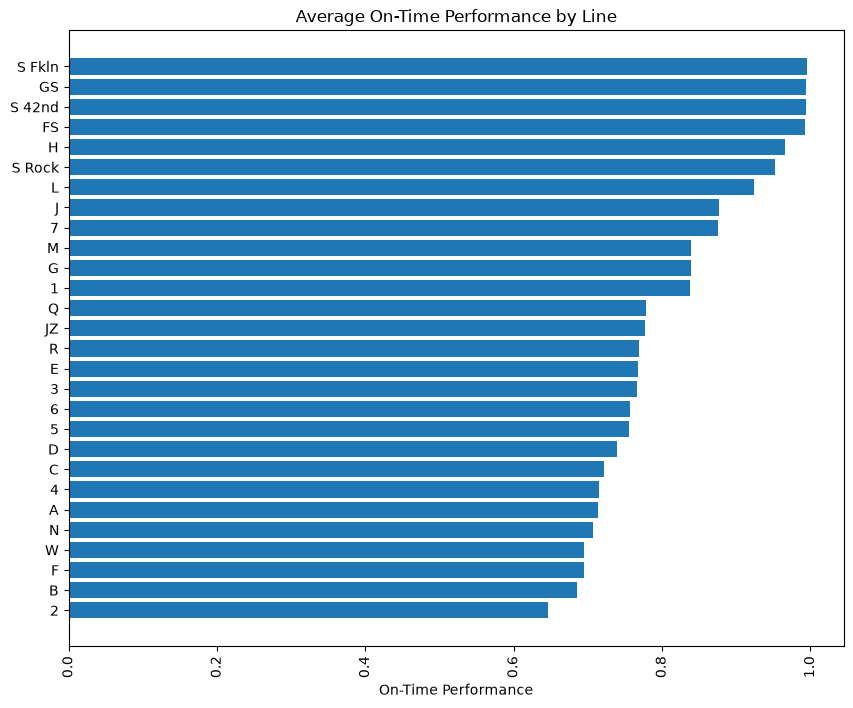

In [79]:
plt.figure(figsize=(10, 8))
plt.title("Average On-Time Performance by Line")
plt.xlabel("MTA Line")
plt.xlabel("On-Time Performance")
plt.barh(line_performance.index, line_performance.values)
plt.xticks(rotation=90)
plt.show()

In [80]:
# Select the best and worst performing lines
top = line_performance.sort_values(ascending=False).head(5)
bottom = line_performance.sort_values().head(5)

subset = pd.concat([bottom, top])
subset = subset.sort_values()

In [85]:
fig = px.bar(
    subset.sort_values(),
    x=subset.values,
    y=subset.index,
    orientation="h",
    title="Best and Worst Performing MTA Lines (2015-2026)",
    labels={
        "x": "Average On-Time Performance",
        "y": "MTA Line"
    }
)

fig.show()

**Insight:**

There is significant variation in on-time performance across subway lines.
Some lines consistently operate near 100% reliability, while others fall below 70%.

This suggests that operational issues may be concentrated on specific lines rather than system-wide.

Exploring on-time performance over time.

In [93]:
monthly_performance = otp_df.groupby("month")["terminal_on_time_performance"].mean()
monthly_performance_df = monthly_performance.reset_index()
monthly_performance_df.columns = ["month", "otp"]
monthly_performance_df

,month,otp
0,2015-01-01,0.724317
1,2015-02-01,0.669369
2,2015-03-01,0.702368
3,2015-04-01,0.724995
4,2015-05-01,0.701130
...,...,...
131,2025-12-01,0.836740
132,2026-01-01,0.842655
133,2026-02-01,0.826622
134,2026-03-01,0.849355


In [116]:
fig = px.line(
    monthly_performance_df,
    x = "month",
    y = "otp",
    title = "MTA On-Time Performance Over Time (2015 - 2026)",
    labels={
        "month": "Date",
        "otp": "On-Time Performance"
    }
)

fig.update_layout(
    template="plotly_white"
)

fig.update_traces(
    line=dict(width=3)
)

fig.update_xaxes(
    dtick="M12",  # Show every 6 months
    tickformat="%Y",
    tickangle=0
)

fig.update_yaxes(
    range=[0.55, 1]
)

# COVID
fig.add_vrect(
    x0="2020-03-01",
    x1="2022-01-01",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="COVID Disruption",
    annotation_position="top left"
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True)

fig.show()

**Insight:**

COVID-19 pandemic led to a two-phase shock in subway reliability: an initial boost (fewer trains + light ridership made schedules easy to keep) followed by sustained volatility once normal service resumed amid crew shortages and disinfecting windows.

Exploring weekday vs weekend on-time performance.

In [114]:
daytype_performance = otp_df.groupby("day_type")["terminal_on_time_performance"].mean()
daytype_df = pd.DataFrame({
    "Day": ["Weekday", "Weekend"],
    "On-Time Performance": [daytype_performance.loc[1], daytype_performance.loc[2]]

})
daytype_df

,Day,On-Time Performance
0,Weekday,0.770094
1,Weekend,0.843008


In [120]:
fig = px.bar(
    daytype_df,
    x="Day",
    y="On-Time Performance",
    text="On-Time Performance", 
    title="Weekday vs Weekend Subway On-Time Performance"
)

fig.update_traces(texttemplate="%{text:.2%}", textposition="outside")
fig.update_layout(
    yaxis=dict(range=[0.55, 0.90]),
    template="plotly_white"
)

fig.update_yaxes(
    range=[0, 1]
)

fig.show()

**Insight:**

Weekend service averages ~6-8 percentage points higher OTP than weekdays, likely because there are fewer trains, less riders, and scheduled work blocks reduce incidental delays. 

Exploring total delays by category.

In [122]:
delays_by_category = (
    delays_df.groupby("Reporting Category")["Incidents"].sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Incidents": "delays", "Reporting Category": "category"})
)
delays_by_category

,category,delays
0,Police & Medical,110959
1,Operating Conditions,103505
2,Infrastructure & Equipment,91108
3,Planned ROW Work,68498
4,Crew Availability,61375
5,External Factors,9297


In [128]:
fig = px.bar(
    delays_by_category,
    x="delays",
    y="category",
    orientation="h",
    text="delays", 
    title="Total Delay-Causing Incidents by Category (2020 – 2026)",
    labels={"delays": "Total Incidents", "category": ""},
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:,}",
    textposition="inside",
    marker_color="#1f77b4"
)

fig.update_layout(
    xaxis_title="Total Number of Delays",
    yaxis_title="Delay Category",
    yaxis=dict(categoryorder="total ascending"),
    margin=dict(l=120)
)

fig.show()

Exploring delays over time by reporting category.

In [129]:
monthly_cat = (
    delays_df.groupby(["Month", "Reporting Category"])["Incidents"]
             .sum()
             .reset_index()
             .rename(columns={"Month": "month",
                              "Reporting Category": "category",
                              "Incidents": "incidents"})
)

In [130]:
fig = px.area(
    monthly_cat,
    x="month",
    y="incidents",
    color="category",
    title="Delay-Causing Incidents Over Time by Category",
    labels={"incidents": "Monthly Incidents", "month": "Date", "category": ""},
    template="plotly_white"
)
fig.update_xaxes(dtick="M6", tickformat="%Y")
fig.show()


---
### Export Clean Data

Aggregated delays table

In [144]:
delays_pivot = delays_df.pivot_table(
    index=["Month", "Line", "Day Type"],
    columns="Reporting Category",
    values="Incidents",
    aggfunc="sum",
    fill_value=0
).reset_index()

delays_pivot.columns.name = None
delays_pivot.head()

,Month,Line,Day Type,Crew Availability,External Factors,Infrastructure & Equipment,Operating Conditions,Planned ROW Work,Police & Medical
0,2020-01-01,1,1,3,2,43,104,35,75
1,2020-01-01,1,2,7,0,13,16,6,22
2,2020-01-01,2,1,8,5,41,80,37,77
3,2020-01-01,2,2,4,1,21,82,12,43
4,2020-01-01,3,1,2,1,24,55,15,32


In [154]:
os.makedirs("../data/processed", exist_ok=True)
delays_pivot.to_csv("../data/processed/delays_clean.csv", index=False)

On-time performance table

In [155]:
otp_df

,month,division,line,day_type,num_on_time_trips,num_sched_trips,terminal_on_time_performance
0,2015-01-01,A DIVISION,1,1,6874,9017,0.762338
1,2015-01-01,A DIVISION,2,1,2920,6175,0.472874
2,2015-01-01,A DIVISION,3,1,4004,5834,0.686322
3,2015-01-01,A DIVISION,4,1,3692,7623,0.484324
4,2015-01-01,A DIVISION,5,1,3203,6491,0.493452
...,...,...,...,...,...,...,...
4997,2026-04-01,B DIVISION,R,2,1554,1724,0.901392
4998,2026-04-01,B DIVISION,S Fkln,1,5234,5236,0.999618
4999,2026-04-01,B DIVISION,S Fkln,2,1904,1904,1.000000
5000,2026-04-01,B DIVISION,S Rock,1,3286,3522,0.932993


In [158]:
otp_df["month"] = pd.to_datetime(otp_df["month"])
otp_df["line"] = otp_df["line"].astype(str)
otp_df["day_type"] = otp_df["day_type"].astype(int)

otp_df = otp_df.rename(columns={"month": "Month", "line": "Line", "day_type": "Day Type"})

In [159]:
otp_df.to_csv("../data/processed/otp_clean.csv", index=False)